# Maximum Likelihood Estimator (MLE)
In this lab, we will show a simple example how MLE works.

Packages used:
- `numpy`: generating an array of random numbers from some common distributions.
- `scipy`: we will use the optimization function from `scipy`

In [1]:
import numpy as np
from scipy.optimize import minimize
from matplotlib import pyplot as plt # plotting

## Gaussian distribution
We will use the example in the lecture notes, the Gaussian distribution.
$$
    L(\mu; \{x_i\}) = \prod_{i=1}^n \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left[-\frac{(x_i - \mu)^2}{2\sigma^2}\right].
$$
Suppose the sigma is given, and we would like to optimize the value of $\mu$.

In [2]:
# first, generate a set of data from a known Gaussian dist

sigma = 1.5
mu = 2.0
def gaussian(x, mu, sigma):
    return 1 / np.sqrt(2 * np.pi * sigma**2) * np.exp(-(x - mu)**2 / (2 * sigma**2))

# numpy.random can directly draw samples from a Gaussian (normal) distribution
np.random.seed(0)
data = np.random.normal(loc=2.0, scale=1.5, size=100) # loc = mu, scale = sigma, size = number of points to draw
print(data)

[ 4.64607852  2.60023581  3.46810698  5.3613398   4.80133699  0.53408318
  3.42513263  1.77296419  1.84517172  2.61589775  2.21606536  4.18141026
  3.14155659  2.18251252  2.66579485  2.50051149  4.24111861  1.6922626
  2.46960155  0.71885639 -1.82948472  2.98042789  3.2966543   0.88675247
  5.40463194 -0.18154851  2.06863778  1.71922422  4.29916882  4.20403815
  2.23242114  2.56724378  0.66832138 -0.9711947   1.47813178  2.23452345
  3.84543602  3.80356977  1.41900977  1.54654587  0.42717055 -0.13002691
 -0.55940529  4.92616309  1.23552173  1.34288855  0.12080696  3.16623553
 -0.42084677  1.68088958  0.65680016  2.58035375  1.23379229  0.22905172
  1.95772666  2.64249781  2.09977583  2.45370785  1.04851686  1.45588825
  0.99130933  1.46067026  0.78028058 -0.5894239   2.26613921  1.3973286
 -0.44529752  2.69417338  0.63905245  2.07791809  3.09363584  2.19347437
  3.70910103  0.14776127  2.60351246  0.97278486  0.69380428  1.1317255
  1.5326712   2.08424801  0.25227524  3.35123973  2.69

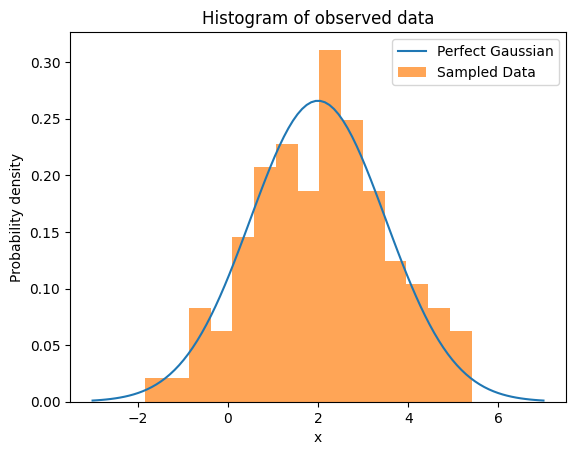

In [3]:
# Visualize the data with histogram
# sample some dots from the perfect gaussian
x = np.linspace(2-5, 2+5, 100)
y = gaussian(x, mu, sigma)
plt.plot(x, y, label="Perfect Gaussian")
plt.hist(data, bins=15, density=True, alpha=0.7, label="Sampled Data")
plt.xlabel("x")
plt.ylabel("Probability density")
plt.title("Histogram of observed data")
plt.legend() # this shows the label of plots
plt.show()

## Maximize the Likelihood to find the mu value
We use the logorithm of $L(\mu; \{x_i\})$
$$
    \ln L(\mu; \{x_i\}) = \sum_{i=1}^n - \left[\frac{1}{2}\ln(2\pi \sigma^2)  +\frac{(x_i - \mu)^2}{2\sigma^2}\right].
$$
Since the constant $\frac{1}{2}\ln(2\pi \sigma^2)$ doesn't affect the optimization result, the problem turns into
$$
\arg\min_\mu \frac{1}{2\sigma^2}\sum_{i=1}^n (x_i - \mu)^2
$$

In [4]:
def cost_func_mu(mu, data, sigma):
    mu = mu[0]  # optimizer passes array
    return 0.5 / sigma**2 * np.sum((data - mu)**2)

In [5]:
mu0 = np.array([0.0])  # initial guess

# call the minimize function from scipy
result = minimize(
    cost_func_mu,
    mu0,
    args=(data, sigma),
    method="BFGS"
)

mu_mle = result.x[0]
print("The mu value estimated by MLE: ", mu_mle)
print("The mean of the data: ", np.mean(data))

The mu value estimated by MLE:  2.0897118931749654
The mean of the data:  2.089712023301728


### Finally, let's see how well this estimator is

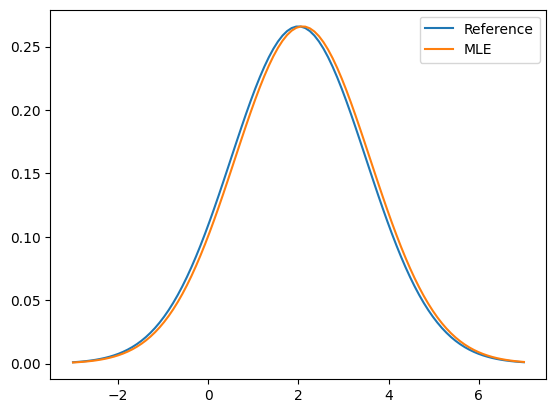

In [6]:
x = np.linspace(2-5, 2+5, 100)
y = gaussian(x, mu, sigma)
y_mle = gaussian(x, mu_mle, sigma)
plt.plot(x, y, label="Reference")
plt.plot(x, y_mle, label="MLE")
plt.legend()

## Standard Error and Confidence Interval

In [12]:
# Sample standard deviation (ddof=1 for unbiased estimator)
S = np.std(data, ddof=1)
# Standard error of the mean
n = len(data)
SE = S / np.sqrt(n)

In [16]:
# 95% confidence interval (Gaussian, large-sample)
# You can try: 90% z = 1.645; 99% z = 2.576
z = 1.96
CI_lower = mu_mle - z * SE
CI_upper = mu_mle + z * SE

In [17]:
print("True mean value: ", mu)
print(f"MLE estimation of mu: {mu_mle:.4f}")
print(f"Standard Error of the estimate: {SE:.4f}")
print(f"95% confidence interval: [{CI_lower:.4f}, {CI_upper:.4f}]")

True mean value:  2.0
MLE estimation of mu: 2.0897
Standard Error of the estimate: 0.1519
95% confidence interval: [1.7919, 2.3875]
